# 다이캐스팅 공정 분석

불량률 최소화를 위한 공정 조건, 센서 패턴, 제품 타입별 운영 기준 확인.

원본 7,535행 × 57열. Process 17개, Sensor 14개, Defects 26개.  
충전불량 8.9%, 기포/내부 5.9%, 표면손상 6.6% 중심 분석.

In [1]:
# 라이브러리
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '1'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import shap
import warnings

from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# CatBoost
try:
    from catboost import CatBoostClassifier
    USE_CATBOOST = True
    print('CatBoost')
except ImportError:
    USE_CATBOOST = False
    print('CatBoost 미사용')

# SMOTE
try:
    from imblearn.over_sampling import SMOTE
    USE_SMOTE = True
    print('SMOTE')
except ImportError:
    USE_SMOTE = False
    print('SMOTE 미사용')

warnings.filterwarnings('ignore')
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

C:\Users\ckcma\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


CatBoost


SMOTE


In [2]:
# 데이터 로드
df_raw = pd.read_csv('DieCasting_Quality_Raw_Data.csv', header=[0, 1])

# 행/열
print(df_raw.shape)

# 그룹별 컬럼 개수 및 결측치 확인
col_cnt = pd.Series({
    group: len([c for c in df_raw.columns if c[0] == group])
    for group in ['Process', 'Sensor', 'Defects']
})
display(col_cnt)

missing = df_raw.isnull().sum()
missing = missing[missing > 0]
missing

(7535, 57)


Process    17
Sensor     14
Defects    26
dtype: int64

Sensor  Factory_Temp            90
        Factory_Temp_Min        90
        Factory_Temp_Max        90
        Factory_Humidity        90
        Factory_Humidity_Min    90
        Factory_Humidity_Max    90
dtype: int64

EDA
Process/Sensor 변수 분포 확인

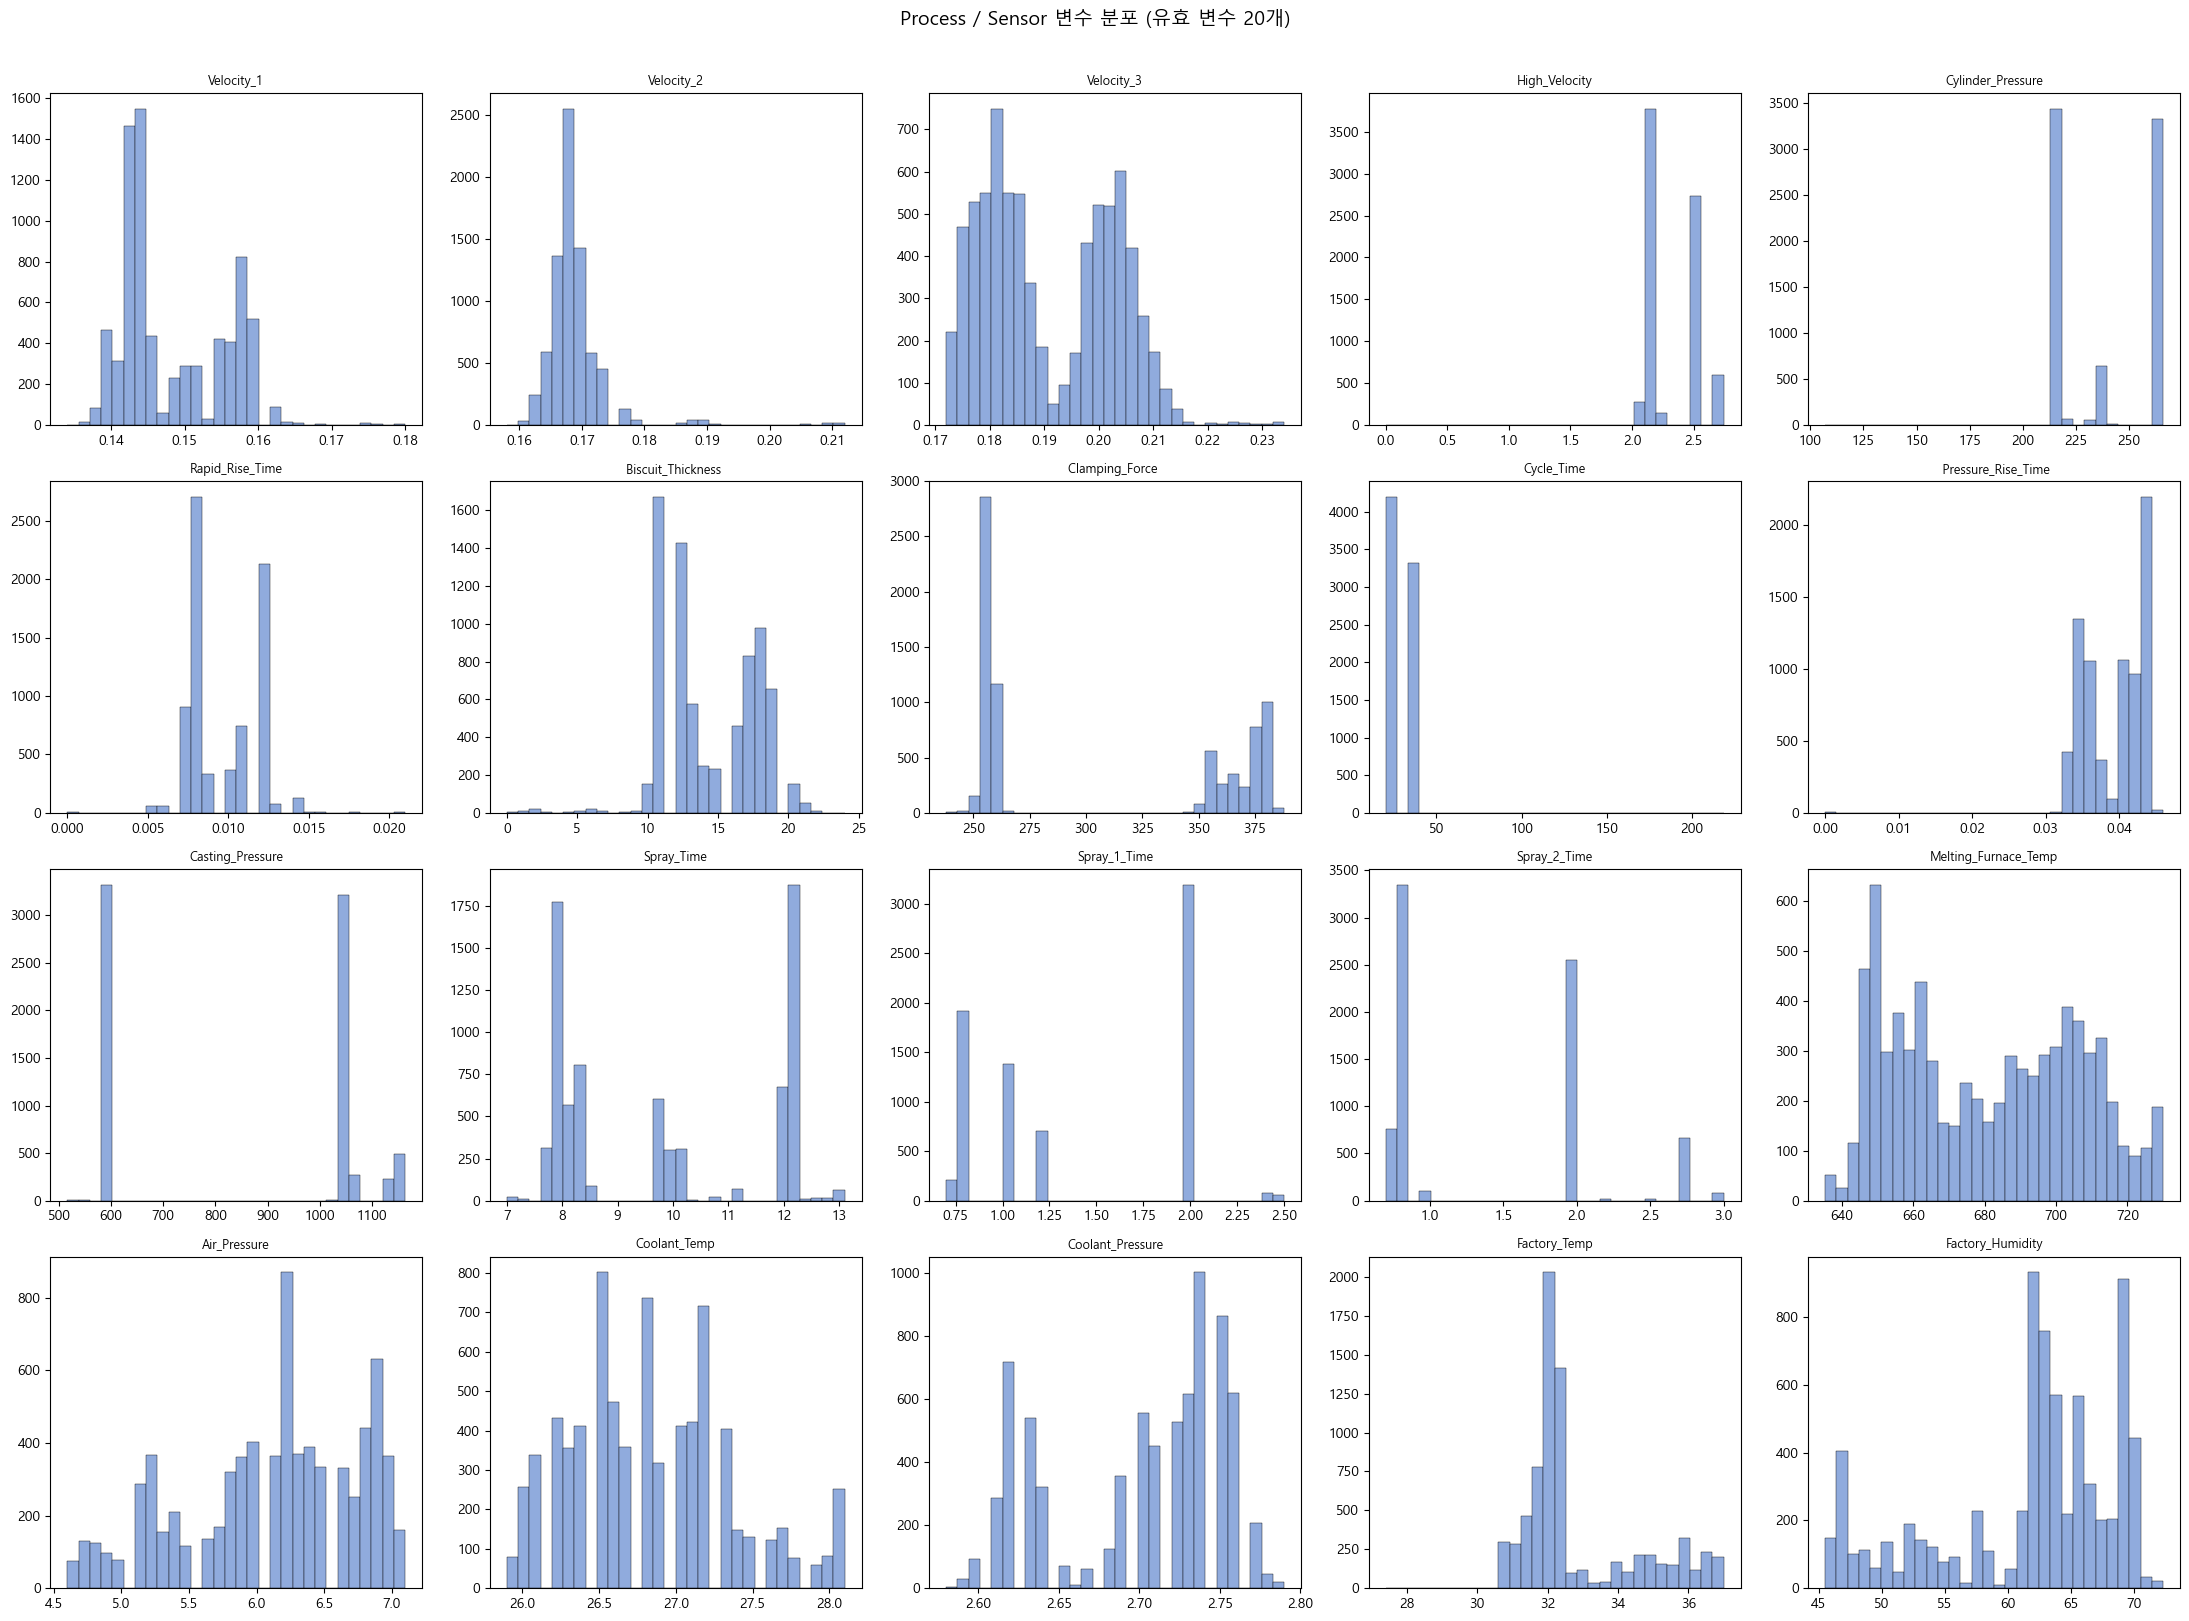

In [3]:
# 공정·센서 변수 분포 확인
process_cols = [c for c in df_raw.columns 
                if c[0] == 'Process' and c[1] not in ['id', 'Product_Type', 'Shot']]
sensor_cols  = [c for c in df_raw.columns if c[0] == 'Sensor']

# # 단일값 변수 제외 (단일 막대)
plot_cols = [c for c in process_cols + sensor_cols
             if pd.to_numeric(df_raw[c], errors='coerce').nunique() > 1]

# 그리드 크기 자동 계산
n = len(plot_cols)
ncols = 5
nrows = -(-n // ncols)  # 올림 나눗셈

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 4 * nrows))
axes = axes.flatten()

# 변수별 분포 시각화
for i, col in enumerate(plot_cols):
    ax = axes[i]
    data = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    ax.hist(data, bins=30, color='#90ABDD', edgecolor='black', linewidth=0.3)
    ax.set_title(f"{col[1]}", fontsize=9)
    
# 빈 subplot 비활성화
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Process / Sensor 변수 분포 (유효 변수 {n}개)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 상관관계 히트맵
불량과 단일 변수 상관 대부분 0.2 이하
복합 조건 기반 모델 필요

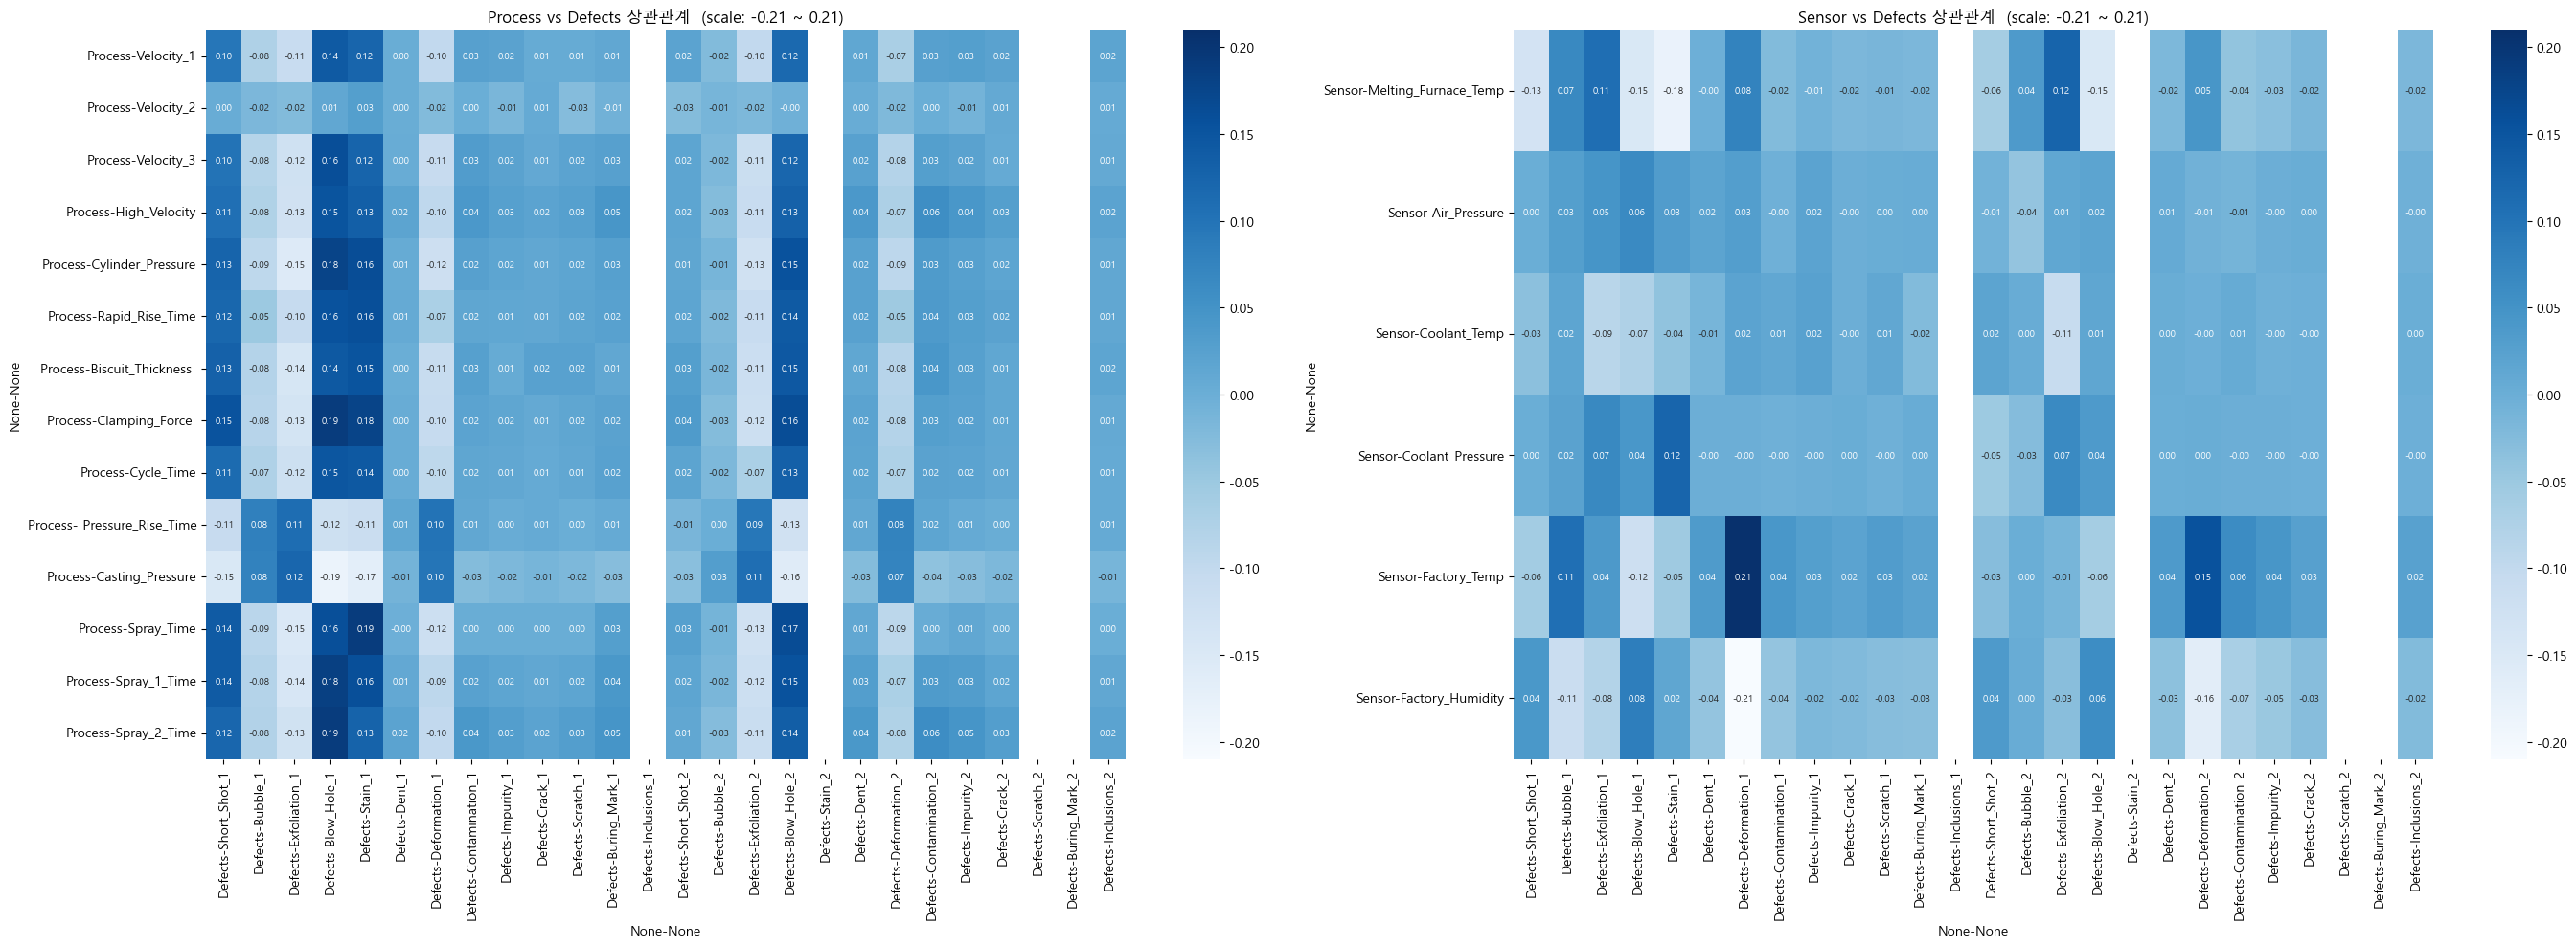

corr_min   -0.21
corr_max    0.21
dtype: float64

In [4]:
# 불량 변수 추출
defect_cols = [c for c in df_raw.columns if c[0] == 'Defects']

# min/max 파생 변수 제외
proc_use = [c for c in process_cols if not any(k in c[1].lower() for k in ['min', 'max'])]
sens_use = [c for c in sensor_cols  if not any(k in c[1].lower() for k in ['min', 'max'])]

# 수치형 변환 및 결측치 보정
df_proc = df_raw[proc_use].apply(pd.to_numeric, errors='coerce').fillna(df_raw[proc_use].apply(pd.to_numeric, errors='coerce').median())
df_sens = df_raw[sens_use].apply(pd.to_numeric, errors='coerce').fillna(df_raw[sens_use].apply(pd.to_numeric, errors='coerce').median())
df_def  = df_raw[defect_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# 공정·불량 상관계수 계산
proc_def_corr = pd.concat([df_proc, df_def], axis=1).corr().loc[df_proc.columns, df_def.columns]

# 센서·불량 상관계수 계산
sens_def_corr = pd.concat([df_sens, df_def], axis=1).corr().loc[df_sens.columns, df_def.columns]

# 히트맵 색상 범위 통일
all_vals = pd.concat([proc_def_corr, sens_def_corr])
vmax =  round(all_vals.abs().max().max(), 2)
vmin = -vmax  # 대칭 스케일


fig, axes = plt.subplots(1, 2, figsize=(28, 10))

# Process-Defects 상관 히트맵
sns.heatmap(proc_def_corr, annot=True, fmt='.2f', cmap='Blues',
            center=0, vmin=vmin, vmax=vmax,
            annot_kws={'size': 7}, ax=axes[0])
axes[0].set_title(f"Process vs Defects 상관관계  (scale: {vmin:.2f} ~ {vmax:.2f})")

# Sensor-Defects 상관 히트맵
sns.heatmap(sens_def_corr, annot=True, fmt='.2f', cmap='Blues',
            center=0, vmin=vmin, vmax=vmax,
            annot_kws={'size': 7}, ax=axes[1])
axes[1].set_title(f"Sensor vs Defects 상관관계  (scale: {vmin:.2f} ~ {vmax:.2f})")

plt.tight_layout()
plt.show()

# 상관계수 범위 확인
pd.Series({'corr_min': round(vmin, 2), 'corr_max': round(vmax, 2)})

이상치
Process 이상치 행 221개, Sensor 이상치 행 2개
제거보다 트리 기반 모델로 강건 처리

In [5]:
# Z-score 이상치
Z_THRESHOLD = 3.0

# 이상치 건수 집계 함수
def zscore_analysis(df_in):
    df_num = df_in.apply(pd.to_numeric, errors='coerce')
    df_num = df_num.fillna(df_num.median())
    # 표준화(Z-score)
    scaler = StandardScaler()
    z = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns, index=df_num.index)
    
    # 임계치 초과 이상치 마스킹
    mask = z.abs() > Z_THRESHOLD
    return {
        'rows_with_outlier': int(mask.any(axis=1).sum()),
        'outlier_cells': int(mask.sum().sum())
    }
# 공정 변수 이상치 집계
proc_out = zscore_analysis(df_proc)

# 센서 변수 이상치 집계
sens_out = zscore_analysis(df_sens)

# 이상치 요약 테이블
pd.DataFrame([proc_out, sens_out], index=['Process', 'Sensor'])

,rows_with_outlier,outlier_cells
Process,221,279
Sensor,2,2


### Welch t-test

Bubble_1 · Stain_1 · Exfoliation_1  
유의 변수 20개 확인

불량 유형별 유의 변수 수 비교 후 모델링·SHAP 해석 기준으로 활용
- sig_count : 통계적으로 유의한 변수 수 (p < 0.05) 
- n_defect : 해당 불량 유형의 발생 건수

In [6]:
# Welch t-test 유의수준 설정
alpha = 0.05

# 불량 여부 이진화
df_def_binary = (df_raw[defect_cols] > 0).astype(int)

# 분석 대상 설명변수 결합
feature_cols_flat = proc_use + sens_use
df_features = pd.concat([df_proc, df_sens], axis=1)

# 불량 유형별 변수 차이 검정
ttest_rows = []
for dcol in defect_cols:
    y = df_def_binary[dcol]
    n_defect = y.sum()
    n_good = (y == 0).sum()
    
    # 표본 수 부족 불량 유형 제외
    if n_defect < 5 or n_good < 5:
        continue

    # 정상군 vs 불량군 평균 차이 검정
    for fcol in feature_cols_flat:
        x0 = df_features.loc[y == 0, fcol].dropna().values
        x1 = df_features.loc[y == 1, fcol].dropna().values
        t_stat, p_val = ttest_ind(x0, x1, equal_var=False, nan_policy='omit')

        ttest_rows.append({
            'defect': dcol[1], 'feature': fcol[1],
            'n_good': n_good, 'n_defect': n_defect, 'p_value': p_val
        })

# 검정 결과 테이블 생성
ttest_df = pd.DataFrame(ttest_rows)

# 통계적 유의성 판정
ttest_df['is_sig'] = ttest_df['p_value'] < alpha


# 불량 유형별 유의 변수 수 요약
summary = ttest_df.groupby('defect').agg(
    sig_count=('is_sig', 'sum'),
    n_defect=('n_defect', 'max')
).sort_values('sig_count', ascending=False)

summary

,sig_count,n_defect
defect,,
Bubble_1,20,72
Stain_1,20,189
Exfoliation_1,20,173
Blow_Hole_1,19,221
Exfoliation_2,19,131
Deformation_1,19,108
Blow_Hole_2,17,155
Short_Shot_1,17,497
Deformation_2,17,64


전처리
상수 컬럼 8개 제거, 최종 독립변수 21개
결측치 대체는 split 이후 train 기준

In [7]:
# X/y 분리

# 모델 입력 변수 선택
process_cols_model = [c for c in df_raw.columns 
                      if c[0] == 'Process' and c[1] not in ['id', 'Shot']]
# 센서·불량 변수 선택 (Product_Type 포함)
sensor_cols_model  = [c for c in df_raw.columns if c[0] == 'Sensor']
defect_cols_model  = [c for c in df_raw.columns if c[0] == 'Defects']

# X 데이터 구성
X_raw = df_raw[process_cols_model + sensor_cols_model].copy()

# 수치형 변환
X_raw = X_raw.apply(pd.to_numeric, errors='coerce')

# 상수 컬럼 제거
nunique = X_raw.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
X_raw = X_raw.drop(columns=constant_cols)
print(len(constant_cols))

# MultiIndex 컬럼명 문자열 변환
X_raw.columns = [f"{a}|{b}" for a, b in X_raw.columns]
print(X_raw.shape[1])

8
21


In [8]:
# 불량 그룹핑
# 그룹핑 기준:
#   충전불량: Short Shot (금형 내 용탕이 미충전)
#   기포/내부: Bubble + Blow Hole (내부 가스 결함)
#   표면손상: Dent, Scratch, Stain, Buring_Mark, Exfoliation (외관 결함)
#   기타: Crack, Deformation, Impurity, Contamination, Inclusions (빈도 낮은 구조/이물 결함)

group_defect = {
    "충전불량": [("Defects","Short_Shot_1"), ("Defects","Short_Shot_2")],
    "기포/내부": [("Defects","Bubble_1"), ("Defects","Blow_Hole_1"),
                 ("Defects","Bubble_2"), ("Defects","Blow_Hole_2")],
    "표면손상": [("Defects","Dent_1"), ("Defects","Scratch_1"), ("Defects","Stain_1"),
                ("Defects","Buring_Mark_1"), ("Defects","Exfoliation_1"),
                ("Defects","Dent_2"), ("Defects","Scratch_2"), ("Defects","Stain_2"),
                ("Defects","Buring_Mark_2"), ("Defects","Exfoliation_2")],
    "기타": [("Defects","Crack_1"), ("Defects","Deformation_1"), ("Defects","Impurity_1"),
            ("Defects","Contamination_1"), ("Defects","Inclusions_1"),
            ("Defects","Crack_2"), ("Defects","Deformation_2"), ("Defects","Impurity_2"),
            ("Defects","Contamination_2"), ("Defects","Inclusions_2")]
}

# 불량 여부 이진화 및 그룹 단위 통합
df_defects_binary = (df_raw[defect_cols_model] > 0).astype(int)

Y_group = pd.DataFrame(index=df_raw.index)

# 그룹별 불량 발생 여부 집계
for gname, cols in group_defect.items():
    cols_exist = [c for c in cols if c in df_defects_binary.columns]
    Y_group[gname] = df_defects_binary[cols_exist].max(axis=1).astype(int)

# 불량 그룹 분포 요약
group_cnt = pd.DataFrame({
    'count': Y_group.sum(),
    'ratio_pct': (Y_group.mean() * 100).round(1)
})

group_cnt

,count,ratio_pct
충전불량,670,8.9
기포/내부,442,5.9
표면손상,500,6.6
기타,191,2.5


### 학습 보조 함수

SMOTE 적용 기준 정리
모델 비교용 공통 함수

- 학습 fold 기준 불균형 보정
- 검증/테스트 원본 분포 유지
- 최종 테스트 임계값 탐색 제외


In [ ]:
# 학습 보조 함수

def split_train_valid_test(X, y, test_size=0.2, valid_size=0.25, random_state=42):
    # 최종 Test Holdout
    X_train_valid, X_test, y_train_valid, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    # Train/Valid 분리
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_valid, y_train_valid,
        test_size=valid_size, random_state=random_state, stratify=y_train_valid
    )

    # Train 기준 결측 대체
    train_median = X_train.median()
    X_train = X_train.fillna(train_median)
    X_valid = X_valid.fillna(train_median)
    X_test = X_test.fillna(train_median)
    X_train_valid = X_train_valid.fillna(train_median)

    # Split 결과 캐시
    return {
        'X_train': X_train, 'X_valid': X_valid, 'X_test': X_test,
        'y_train': y_train, 'y_valid': y_valid, 'y_test': y_test,
        'X_train_valid': X_train_valid, 'y_train_valid': y_train_valid,
        'train_median': train_median
    }


def apply_smote(X_train, y_train, random_state=42):
    # 소수 클래스 수
    minority_n = y_train.value_counts().min()
    if minority_n < 2:
        return X_train, y_train
    # k_neighbors 보정
    k = min(5, minority_n - 1)

    # Train SMOTE
    smote = SMOTE(random_state=random_state, k_neighbors=k)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    return X_res, y_res


def get_models(spw=1.0):
    # 모델 후보
    return {
        "RandomForest": RandomForestClassifier(
            n_estimators=200, random_state=42, n_jobs=1, class_weight="balanced"
        ),
        "LightGBM": LGBMClassifier(
            n_estimators=600, learning_rate=0.05, max_depth=-1,
            num_leaves=31, subsample=0.9, colsample_bytree=0.9,
            random_state=42, n_jobs=1, verbosity=-1
        ),
        "XGBoost": XGBClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=5,
            subsample=0.9, colsample_bytree=0.9,
            random_state=42, n_jobs=1, eval_metric="logloss",
            scale_pos_weight=spw
        ),
        "CatBoost": CatBoostClassifier(
            iterations=600, learning_rate=0.05, depth=6,
            l2_leaf_reg=3, subsample=0.9,
            auto_class_weights="Balanced",
            random_seed=42, verbose=0,
            eval_metric="F1",
            allow_writing_files=False
        ),
    }


def evaluate_model(y_true, y_pred, y_proba):
    # 분류 성능 지표
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "cm":        confusion_matrix(y_true, y_pred),
        "pr_auc":    average_precision_score(y_true, y_proba),
        "roc_auc":   roc_auc_score(y_true, y_proba),
    }


def cross_validate_models(X, y, gname, n_splits=5):
    # Stratified 5-Fold CV
    # train fold만 결측 대체·SMOTE
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    model_names = list(get_models().keys())
    metric_names = ['accuracy', 'precision', 'recall', 'f1', 'pr_auc', 'roc_auc']

    scores = {}
    for m in model_names:
        scores[m] = {}
        for metric in metric_names:
            scores[m][metric] = []

    for train_idx, val_idx in skf.split(X, y):
        # Fold 인덱스 분리
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Fold Train 결측 기준
        med = X_tr.median()
        X_tr = X_tr.fillna(med)
        X_val = X_val.fillna(med)

        # Train Fold SMOTE
        X_sm, y_sm = apply_smote(X_tr, y_tr)

        # 불균형 가중치
        pos = (y_sm == 1).sum()
        neg = (y_sm == 0).sum()
        spw = neg / pos if pos > 0 else 1

        for mname, model in get_models(spw).items():
            # Fold 모델 학습
            model.fit(X_sm, y_sm)
            # Validation 예측
            proba = model.predict_proba(X_val)[:, 1]
            # 임계값 = 0.5 고정 (threshold=0.5)
            pred = (proba >= 0.5).astype(int)
            for k, v in evaluate_model(y_val, pred, proba).items():
                if k != 'cm':
                    scores[mname][k].append(v)

    # CV 요약 테이블
    summary = {}
    for m, metrics in scores.items():
        summary[m] = {}
        for metric, values in metrics.items():
            mean_val = np.mean(values)
            std_val = np.std(values)
            summary[m][metric] = f"{mean_val:.3f} ± {std_val:.3f}"

    cv_df = pd.DataFrame(summary).T
    return cv_df


print('학습 fold/split에만 SMOTE 적용, 검증/테스트는 원본 분포 유지')


학습 fold/split에만 SMOTE 적용, 검증/테스트는 원본 분포 유지


### 모델 성능 비교

5-Fold 교차검증 기준 모델 비교
RF·LightGBM 중심 후보 선정

- RandomForest: F1/ROC-AUC 안정, SHAP 해석 기준
- LightGBM: 비교 후보
- XGBoost: 재현율 상대적 제한


교차검증 해석 메모

- Fold별 학습 데이터에만 SMOTE 적용
- 검증 Fold 원본 행 수 유지
- PR-AUC 기준 최종 모델 후보 확인


In [19]:
# CV 성능 비교
# 기타 그룹 제외
# final test 먼저 분리
target_groups = ["충전불량", "기포/내부", "표면손상"]
split_cache = {}

for gname in target_groups:
    # 그룹 라벨 선택
    y = Y_group[gname]
    # Split 캐시
    splits = split_train_valid_test(X_raw, y)
    split_cache[gname] = splits

    # 클래스 분포 확인
    print(f'defect_group: {gname}')
    print('total defect/normal:', int(y.sum()), int((y == 0).sum()))
    print('train_valid defect/normal:', int(splits['y_train_valid'].sum()), int((splits['y_train_valid'] == 0).sum()))
    print('test defect/normal:', int(splits['y_test'].sum()), int((splits['y_test'] == 0).sum()))

    # CV 결과 출력
    cv_result = cross_validate_models(
        splits['X_train_valid'], splits['y_train_valid'], gname, n_splits=5
    )
    cv_display = cv_result.copy()
    cv_display.insert(0, 'defect_group', gname)
    display(cv_display)


defect_group: 충전불량
total defect/normal: 670 6865
train_valid defect/normal: 536 5492
test defect/normal: 134 1373
defect_group: 기포/내부
total defect/normal: 442 7093
train_valid defect/normal: 354 5674
test defect/normal: 88 1419
defect_group: 표면손상
total defect/normal: 500 7035
train_valid defect/normal: 400 5628
test defect/normal: 100 1407


,defect_group,accuracy,precision,recall,f1,pr_auc,roc_auc
RandomForest,충전불량,0.944 ± 0.005,0.751 ± 0.037,0.560 ± 0.047,0.640 ± 0.037,0.660 ± 0.020,0.902 ± 0.020
LightGBM,충전불량,0.948 ± 0.004,0.800 ± 0.026,0.552 ± 0.041,0.653 ± 0.033,0.660 ± 0.025,0.882 ± 0.019
XGBoost,충전불량,0.922 ± 0.001,0.619 ± 0.017,0.313 ± 0.031,0.415 ± 0.027,0.442 ± 0.022,0.845 ± 0.015
CatBoost,충전불량,0.934 ± 0.002,0.724 ± 0.022,0.424 ± 0.029,0.534 ± 0.023,0.556 ± 0.028,0.867 ± 0.013


,defect_group,accuracy,precision,recall,f1,pr_auc,roc_auc
RandomForest,기포/내부,0.964 ± 0.001,0.749 ± 0.016,0.579 ± 0.039,0.652 ± 0.021,0.635 ± 0.042,0.916 ± 0.012
LightGBM,기포/내부,0.966 ± 0.002,0.796 ± 0.038,0.562 ± 0.055,0.656 ± 0.034,0.636 ± 0.035,0.895 ± 0.014
XGBoost,기포/내부,0.947 ± 0.002,0.575 ± 0.028,0.404 ± 0.028,0.473 ± 0.015,0.467 ± 0.018,0.878 ± 0.011
CatBoost,기포/내부,0.957 ± 0.003,0.689 ± 0.045,0.480 ± 0.029,0.565 ± 0.025,0.544 ± 0.031,0.890 ± 0.020


,defect_group,accuracy,precision,recall,f1,pr_auc,roc_auc
RandomForest,표면손상,0.953 ± 0.003,0.710 ± 0.040,0.485 ± 0.062,0.574 ± 0.044,0.574 ± 0.042,0.910 ± 0.015
LightGBM,표면손상,0.953 ± 0.006,0.735 ± 0.077,0.470 ± 0.063,0.571 ± 0.059,0.587 ± 0.050,0.889 ± 0.018
XGBoost,표면손상,0.935 ± 0.002,0.525 ± 0.027,0.285 ± 0.060,0.366 ± 0.052,0.422 ± 0.051,0.862 ± 0.020
CatBoost,표면손상,0.944 ± 0.001,0.633 ± 0.022,0.372 ± 0.037,0.468 ± 0.028,0.488 ± 0.044,0.871 ± 0.019


In [1]:
# SMOTE 적용 전후 클래스 분포 확인
# 기준 데이터: 그룹별 Train split, 최종 Train+Valid split

smote_count_rows = []

for gname in target_groups:
    splits = split_cache[gname]
    check_sets = {
        'Train': (splits['X_train'], splits['y_train']),
        'Train+Valid': (
            pd.concat([splits['X_train'], splits['X_valid']], axis=0),
            pd.concat([splits['y_train'], splits['y_valid']], axis=0)
        )
    }

    for split_name, (X_base, y_base) in check_sets.items():
        X_sm, y_sm = apply_smote(X_base, y_base)
        before = y_base.value_counts().reindex([0, 1], fill_value=0)
        after = pd.Series(y_sm).value_counts().reindex([0, 1], fill_value=0)

        smote_count_rows.append({
            'defect_group': gname,
            'split': split_name,
            'before_normal_0': int(before[0]),
            'before_defect_1': int(before[1]),
            'after_normal_0': int(after[0]),
            'after_defect_1': int(after[1]),
            'added_samples': int(len(y_sm) - len(y_base))
        })

smote_count_df = pd.DataFrame(smote_count_rows)

for _, row in smote_count_df[smote_count_df['split'] == 'Train+Valid'].iterrows():
    before_total = row['before_normal_0'] + row['before_defect_1']
    after_total = row['after_normal_0'] + row['after_defect_1']
    print(f"SMOTE: {before_total:,} \u2192 {after_total:,} {row['defect_group']}")

display(smote_count_df)


SMOTE: 6,028 → 10,984 충전불량
SMOTE: 6,028 → 11,348 기포/내부
SMOTE: 6,028 → 11,256 표면손상


,defect_group,split,before_normal_0,before_defect_1,after_normal_0,after_defect_1,added_samples
0,충전불량,Train,4119,402,4119,4119,3717
1,충전불량,Train+Valid,5492,536,5492,5492,4956
2,기포/내부,Train,4255,266,4255,4255,3989
3,기포/내부,Train+Valid,5674,354,5674,5674,5320
4,표면손상,Train,4221,300,4221,4221,3921
5,표면손상,Train+Valid,5628,400,5628,5628,5228


### 임계값 탐색

PR Curve 기준 운영 임계값 선택

- 검증 데이터 기준 최적값 탐색
- 최종 테스트 평가 전 임계값 고정
- 정밀도/재현율 근거 확인


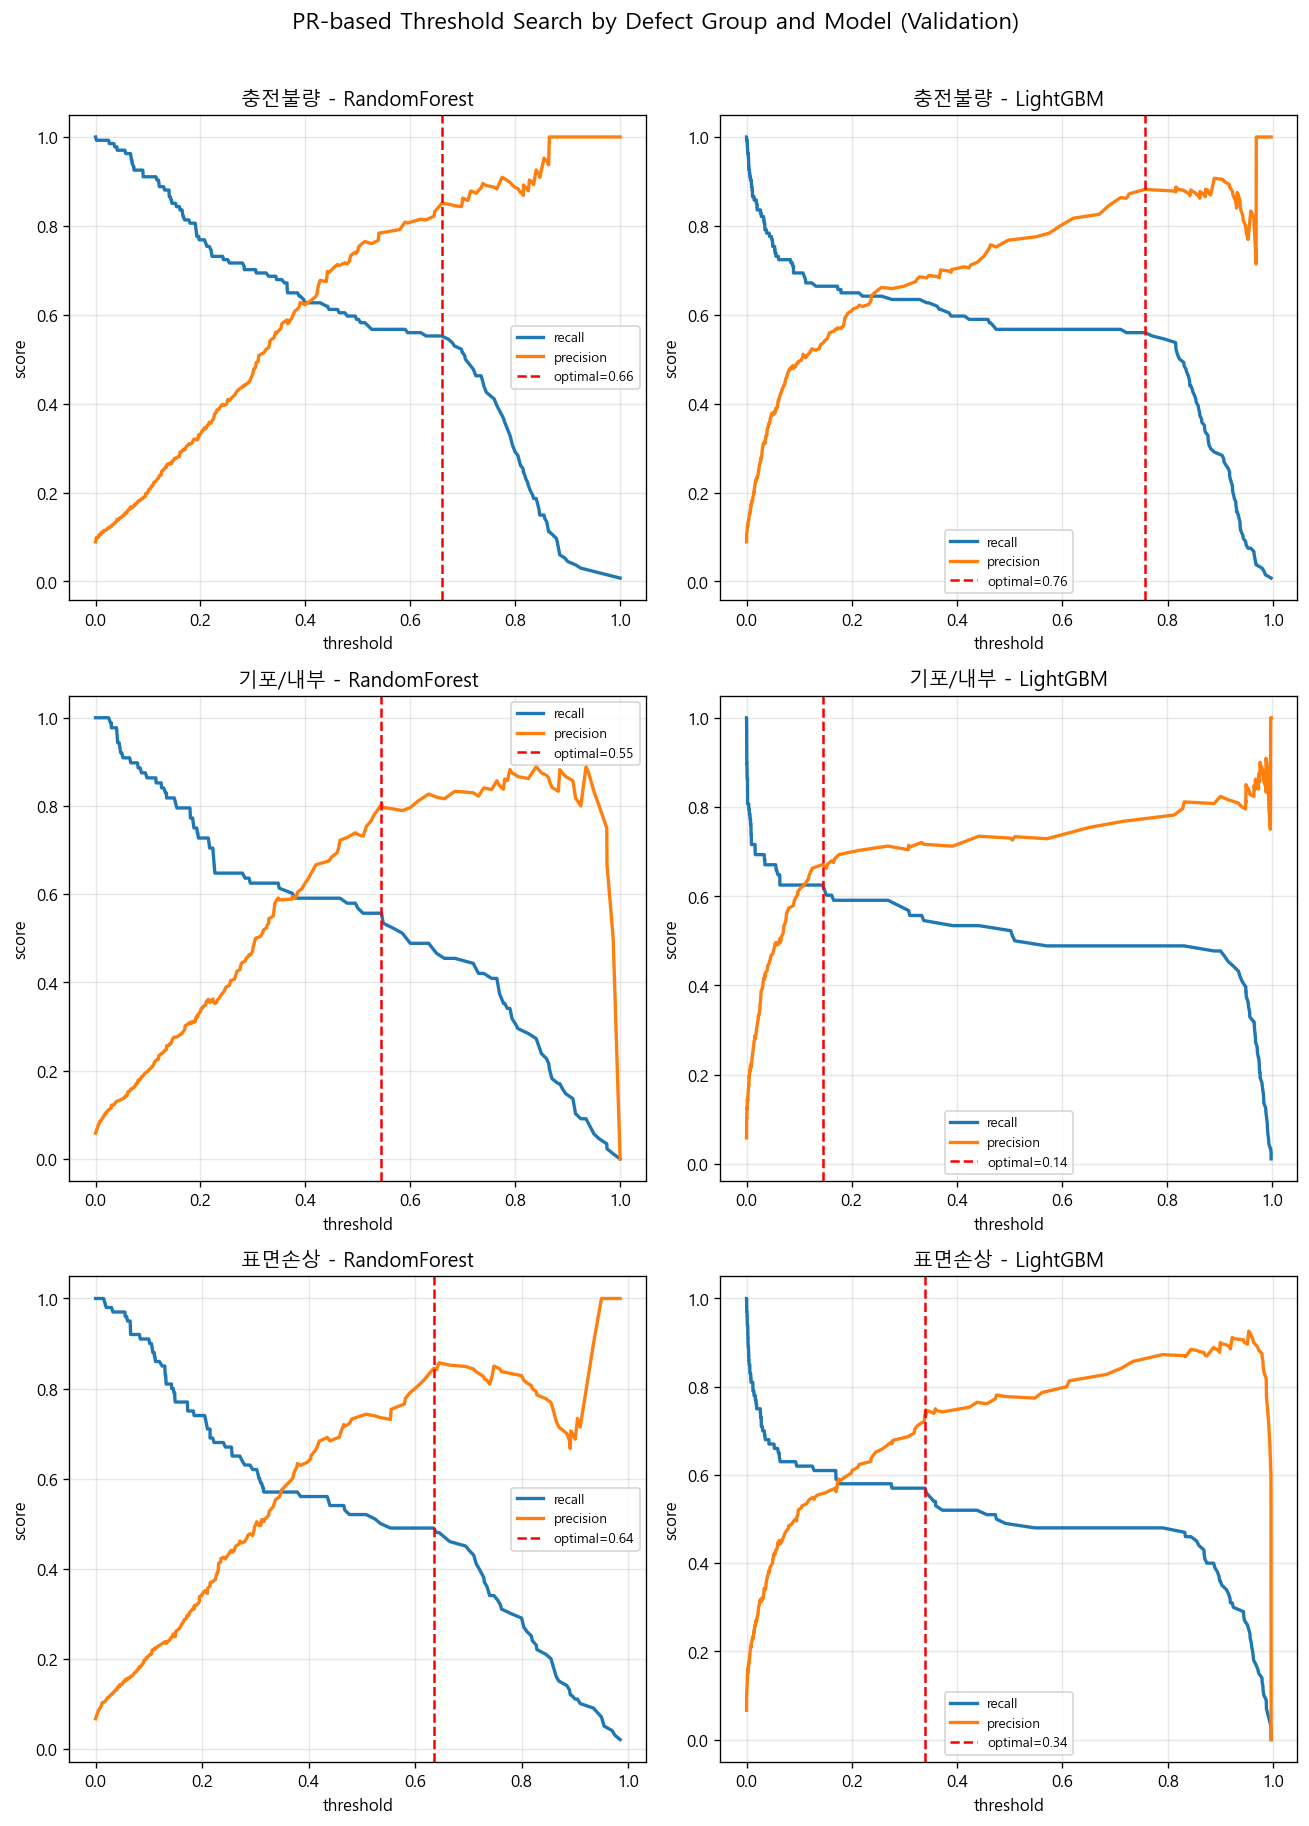

,group,model,optimal_threshold,valid_f1_at_threshold,valid_pr_auc,valid_roc_auc
0,충전불량,RandomForest,0.660,0.670,0.683,0.907
1,충전불량,LightGBM,0.758,0.685,0.657,0.891
2,기포/내부,RandomForest,0.545,0.658,0.608,0.923
3,기포/내부,LightGBM,0.145,0.647,0.597,0.886
4,표면손상,RandomForest,0.635,0.620,0.593,0.916
5,표면손상,LightGBM,0.339,0.644,0.599,0.904


In [22]:
# PR 기준 Threshold
# RF·LightGBM

SELECTED_MODELS = ["RandomForest", "LightGBM"]

def find_optimal_threshold(y_true, proba, beta=1.0):
    # PR Curve 계산
    prec_arr, rec_arr, thr_arr = precision_recall_curve(y_true, proba)
    prec_arr = prec_arr[:-1]
    rec_arr  = rec_arr[:-1]
    # F1 최대 Threshold
    fbeta = ((1 + beta**2) * prec_arr * rec_arr) / (beta**2 * prec_arr + rec_arr + 1e-10)
    best_idx = np.argmax(fbeta)
    return thr_arr[best_idx], fbeta[best_idx], prec_arr, rec_arr, thr_arr


# Threshold 시각화 영역
fig, axes = plt.subplots(len(target_groups), len(SELECTED_MODELS),
                         figsize=(5.5 * len(SELECTED_MODELS), 5 * len(target_groups)))
if len(target_groups) == 1:
    axes = axes.reshape(1, -1)

threshold_results = []

for r, gname in enumerate(target_groups):
    # 그룹별 Split
    splits = split_cache.get(gname) or split_train_valid_test(X_raw, Y_group[gname])
    X_train, y_train = splits['X_train'], splits['y_train']
    X_valid, y_valid = splits['X_valid'], splits['y_valid']

    # Train SMOTE
    X_train_sm, y_train_sm = apply_smote(X_train, y_train)

    # 불균형 가중치
    pos = (y_train_sm == 1).sum()
    neg = (y_train_sm == 0).sum()
    spw = neg / pos if pos > 0 else 1

    # 선택 모델
    all_models = get_models(spw=spw)
    models = {}
    for name, model in all_models.items():
        if name in SELECTED_MODELS:
            models[name] = model

    for c, (mname, model) in enumerate(models.items()):
        # Validation 예측
        model.fit(X_train_sm, y_train_sm)
        proba = model.predict_proba(X_valid)[:, 1]

        # Threshold 탐색
        opt_thr, opt_fbeta, prec_arr, rec_arr, thr_arr = find_optimal_threshold(y_valid, proba)

        # Precision/Recall 시각화
        ax = axes[r, c]
        ax.plot(thr_arr, rec_arr, label='recall', linewidth=2)
        ax.plot(thr_arr, prec_arr, label='precision', linewidth=2)
        ax.axvline(opt_thr, color='red', linestyle='--', linewidth=1.5,
                   label=f'optimal={opt_thr:.2f}')
        ax.set_title(f'{gname} - {mname}')
        ax.set_xlabel('threshold')
        ax.set_ylabel('score')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)

        # Validation 지표 저장
        threshold_results.append({
            'group': gname, 'model': mname,
            'optimal_threshold': round(opt_thr, 3),
            'valid_f1_at_threshold': round(opt_fbeta, 3),
            'valid_pr_auc': round(average_precision_score(y_valid, proba), 3),
            'valid_roc_auc': round(roc_auc_score(y_valid, proba), 3),
        })

plt.suptitle('PR-based Threshold Search by Defect Group and Model (Validation)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Threshold 결과표
thr_df = pd.DataFrame(threshold_results)
thr_display = thr_df.copy()
display(thr_display)


### 최종 성능 평가

검증 기준 임계값 고정 후 최종 테스트 평가
RF·LightGBM 최종 비교

SHAP 해석 기준 모델: RandomForest


In [24]:
# 최종 Test 평가

SELECTED_MODELS = ["RandomForest", "LightGBM"]
final_results = {}

for gname in target_groups:
    # 그룹별 Split
    splits = split_cache.get(gname) or split_train_valid_test(X_raw, Y_group[gname])
    # 최종 Test 분리
    X_test, y_test = splits['X_test'], splits['y_test']

    # Threshold 고정 후 Train+Valid 학습
    # Test 평가만 사용
    X_train_ref = pd.concat([splits['X_train'], splits['X_valid']], axis=0)
    y_train_ref = pd.concat([splits['y_train'], splits['y_valid']], axis=0)
    # Train+Valid SMOTE
    X_train_sm, y_train_sm = apply_smote(X_train_ref, y_train_ref)

    # 불균형 가중치
    pos = (y_train_sm == 1).sum()
    neg = (y_train_sm == 0).sum()
    spw = neg / pos if pos > 0 else 1

    # 최종 비교 모델
    all_models = get_models(spw=spw)
    models = {}
    for name, model in all_models.items():
        if name in SELECTED_MODELS:
            models[name] = model

    print(gname)

    for mname, model in models.items():
        # 최종 모델 학습
        model.fit(X_train_sm, y_train_sm)
        proba = model.predict_proba(X_test)[:, 1]

        # Validation Threshold 적용
        row = thr_df[(thr_df['group'] == gname) & (thr_df['model'] == mname)]
        opt_thr = row['optimal_threshold'].values[0]

        # Test 성능 산출
        pred = (proba >= opt_thr).astype(int)
        metrics = evaluate_model(y_test, pred, proba)

        print(f'모델: {mname} / 임계값: {opt_thr:.2f}')
        print(f"precision {metrics['precision']:.3f} | recall {metrics['recall']:.3f} | f1 {metrics['f1']:.3f} | pr_auc {metrics['pr_auc']:.3f}")
        print('confusion_matrix')
        print(metrics['cm'])

        # 최종 결과 저장
        result = metrics.copy()
        result['threshold'] = opt_thr
        result['model_obj'] = model
        result['proba'] = proba
        result['X_test'] = X_test
        result['y_test'] = y_test
        result['X_train'] = X_train_sm
        result['y_train'] = y_train_sm
        result['X_train_ref'] = X_train_ref
        result['y_train_ref'] = y_train_ref
        result['X_valid'] = splits['X_valid']
        result['y_valid'] = splits['y_valid']

        final_results[(gname, mname)] = result

print('최종 비교 모델: RandomForest / LightGBM')


충전불량
모델: RandomForest / 임계값: 0.66
precision 0.924 | recall 0.634 | f1 0.752 | pr_auc 0.779
confusion_matrix
[[1366    7]
 [  49   85]]
모델: LightGBM / 임계값: 0.76
precision 0.958 | recall 0.507 | f1 0.663 | pr_auc 0.796
confusion_matrix
[[1370    3]
 [  66   68]]
기포/내부
모델: RandomForest / 임계값: 0.55
precision 0.810 | recall 0.727 | f1 0.766 | pr_auc 0.694
confusion_matrix
[[1404   15]
 [  24   64]]
모델: LightGBM / 임계값: 0.14
precision 0.650 | recall 0.761 | f1 0.702 | pr_auc 0.791
confusion_matrix
[[1383   36]
 [  21   67]]
표면손상
모델: RandomForest / 임계값: 0.64
precision 0.825 | recall 0.660 | f1 0.733 | pr_auc 0.732
confusion_matrix
[[1393   14]
 [  34   66]]
모델: LightGBM / 임계값: 0.34
precision 0.753 | recall 0.730 | f1 0.741 | pr_auc 0.748
confusion_matrix
[[1383   24]
 [  27   73]]
최종 비교 모델: RandomForest / LightGBM


### SHAP 중요도

충전불량 기준 변수 영향 확인
상위 변수: 고속속도, 형체력, 1차속도, 압력상승시간


충전불량


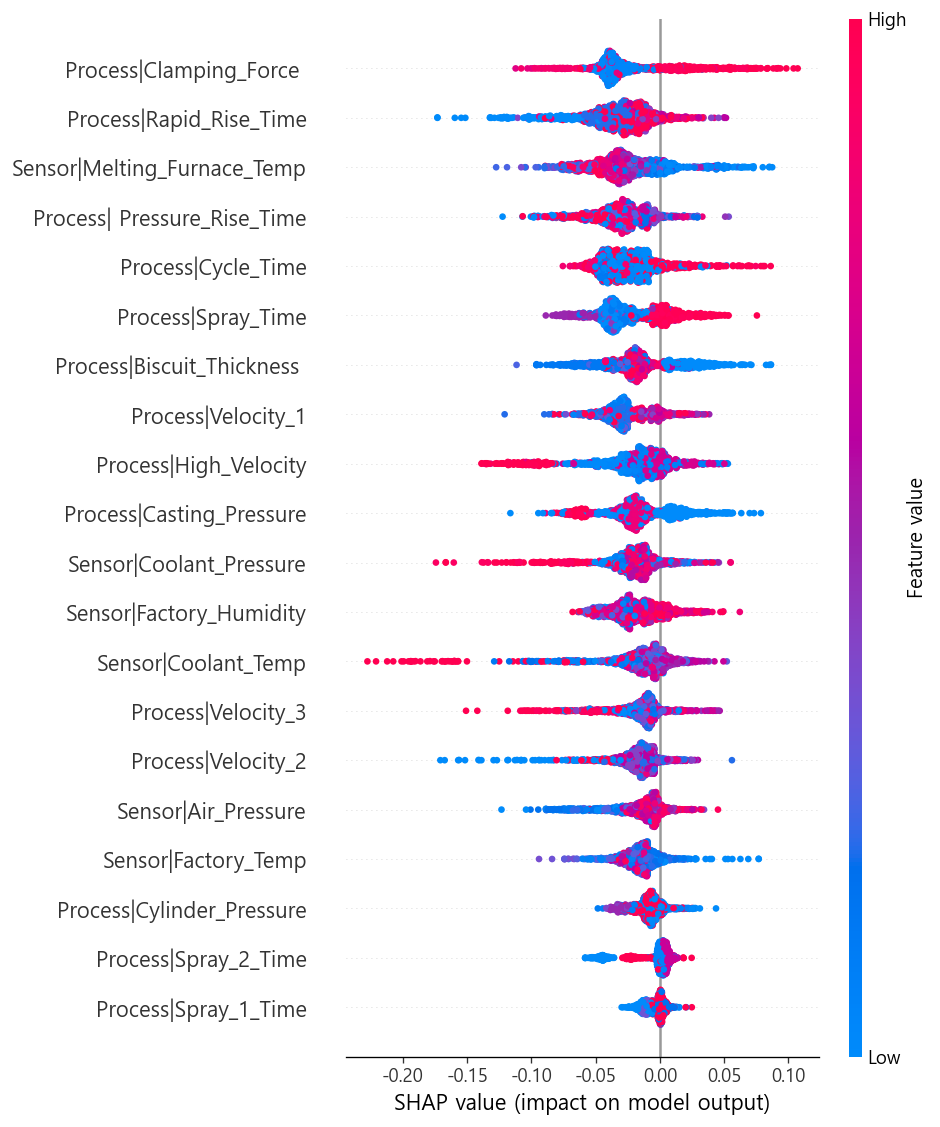

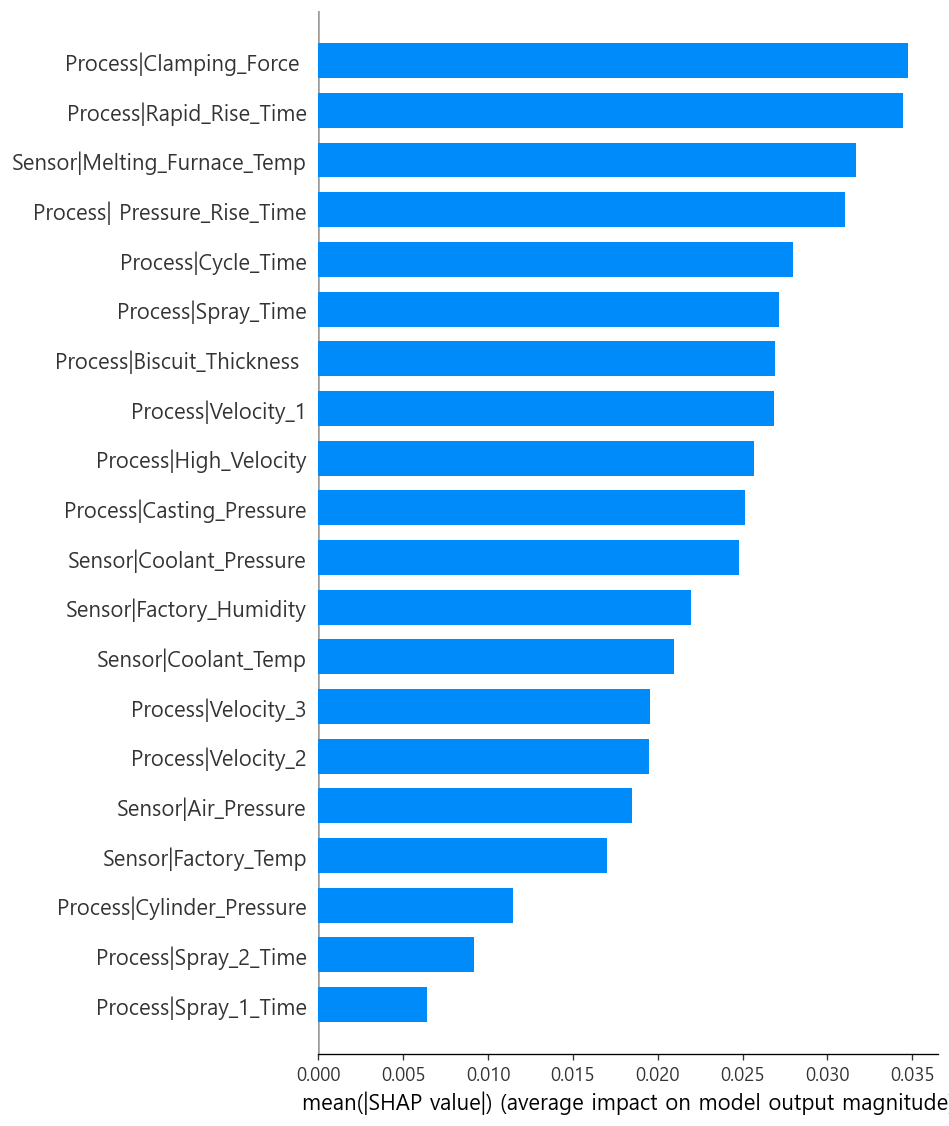

,feature,mean_abs_shap
8,Clamping_Force,0.034746
6,Rapid_Rise_Time,0.034430
15,Melting_Furnace_Temp,0.031692
10,Pressure_Rise_Time,0.031053
9,Cycle_Time,0.027996
12,Spray_Time,0.027119
7,Biscuit_Thickness,0.026888
1,Velocity_1,0.026823
4,High_Velocity,0.025695
11,Casting_Pressure,0.025125


In [26]:
# SHAP: 충전불량
target_group = "충전불량"
key = (target_group, "RandomForest")
res = final_results[key]
model = res['model_obj']
X_test_shap = res['X_test']

# TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_shap)

# 반환 형태 통일 (항상 2D: n_samples × n_features)
if isinstance(shap_values, list):
    shap_vals = shap_values[1] if len(shap_values) > 1 else shap_values[0]
elif hasattr(shap_values, 'values'):
    shap_vals = shap_values.values
else:
    shap_vals = shap_values

if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, -1]

# SHAP 요약 분포
print(target_group)
shap.summary_plot(shap_vals, X_test_shap, show=True)

# SHAP 중요도 막대그래프
shap.summary_plot(shap_vals, X_test_shap, plot_type="bar", show=True)

# 수치 테이블
mean_abs = np.abs(shap_vals).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': X_test_shap.columns,
    'mean_abs_shap': mean_abs
}).sort_values('mean_abs_shap', ascending=False)

shap_display = shap_importance.head(15).copy()
shap_display['feature'] = shap_display['feature'].str.replace('Process|', '', regex=False).str.replace('Sensor|', '', regex=False)
display(shap_display)

# 대시보드 입력 CSV 생성
shap_export = shap_importance.head(10).copy()
shap_export.insert(0, 'target_group', target_group)
shap_export.insert(0, 'model', 'RandomForest')
shap_export = shap_export.rename(columns={'mean_abs_shap': 'importance'})
shap_export['feature'] = shap_export['feature'].str.replace(r'\s*\|\s*', '|', regex=True).str.strip()
shap_export[['model', 'target_group', 'feature', 'importance']].to_csv(
    'diecasting_rf_shap_top10.csv', index=False, encoding='utf-8-sig'
)

실제 라벨: 0
예측 불량확률: 0.034


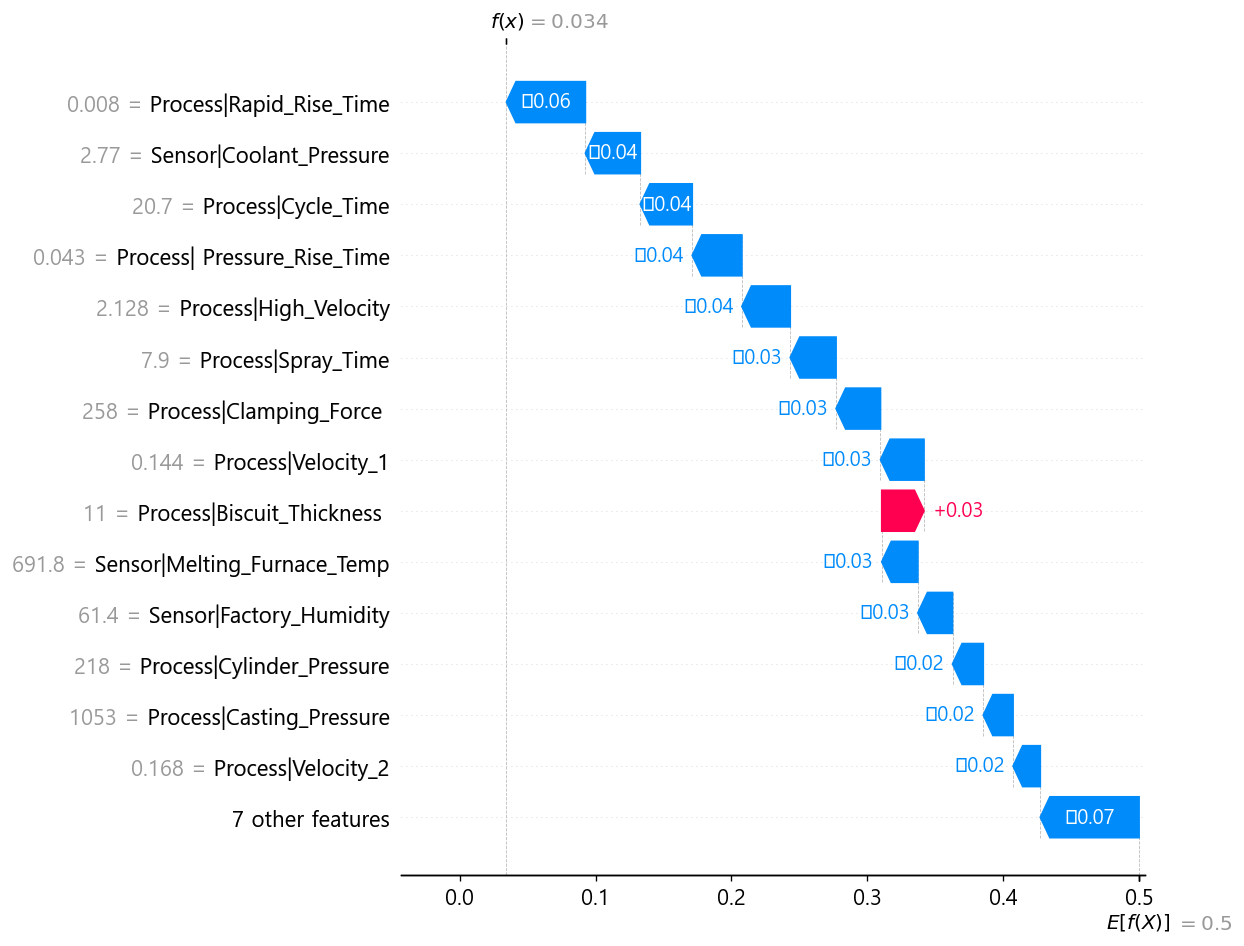

In [27]:
# 개별 샘플 해석
row_idx = 0

base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1] if len(base_val) > 1 else base_val[0]

exp = shap.Explanation(
    values=shap_vals[row_idx],
    base_values=base_val,
    data=X_test_shap.iloc[row_idx].values,
    feature_names=list(X_test_shap.columns)
)
shap.plots.waterfall(exp, max_display=15)

print('실제 라벨:', res['y_test'].iloc[row_idx])
print('예측 불량확률:', round(model.predict_proba(X_test_shap.iloc[[row_idx]])[0, 1], 3))

### 샘플 진단 로직

불량확률, SHAP 방향, 정상 기준 편차 기준 판정
개별 샘플 원인 변수 확인


In [29]:
# 진단 로직
def diagnosis_report(model, explainer, shap_vals, X_test, X_train, y_train, sample_idx=0, top_n=5):
    # 샘플 단위 진단
    
    # 불량 확률
    pred_proba = model.predict_proba(X_test.iloc[[sample_idx]])[0, 1]
    
    # SHAP 상위 변수
    sample_shap = shap_vals[sample_idx]
    shap_df = pd.DataFrame({
        'feature': X_test.columns,
        'shap_value': sample_shap,
        'abs_shap': np.abs(sample_shap)
    }).sort_values('abs_shap', ascending=False)
    
    top_features = shap_df.head(top_n)
    
    # 정상 기준 편차
    normal_median = X_train[y_train == 0].median()
    
    # 위험 판정
    print(f"불량확률 {pred_proba:.1%}")
    if pred_proba >= 0.7:
        print("고위험")
    elif pred_proba >= 0.4:
        print("주의")
    else:
        print("정상")
    print()
    print(f"원인 변수 상위 {top_n}")
    
    for rank, (_, row) in enumerate(top_features.iterrows(), 1):
        feat = row['feature']
        current_val = X_test.iloc[sample_idx][feat]
        normal_val  = normal_median[feat]
        
        if normal_val != 0:
            deviation_pct = (current_val - normal_val) / abs(normal_val) * 100
        else:
            deviation_pct = 0.0
        
        # SHAP 방향 + 편차 크기로 위험 판정
        shap_direction = "불량↑" if row['shap_value'] > 0 else "정상↓"
        
        if row['shap_value'] > 0 and abs(deviation_pct) > 10:
            risk = "⛔ 위험"
        elif row['shap_value'] > 0:
            risk = "⚠️ 주의"
        else:
            risk = "✅ 정상"
        
        feat_short = feat.replace('Process|','').replace('Sensor|','')
        print(f"  {rank}. {feat_short}")
        print(f"     정상 기준: {normal_val:.4f} | 현재: {current_val:.4f} | 편차: {deviation_pct:+.1f}% | SHAP 방향: {shap_direction} | {risk}")



# 실행 예시
diagnosis_report(
    model=final_results[("충전불량","RandomForest")]['model_obj'],
    explainer=explainer,
    shap_vals=shap_vals,
    X_test=final_results[("충전불량","RandomForest")]['X_test'],
    X_train=final_results[("충전불량","RandomForest")]['X_train'],
    y_train=final_results[("충전불량","RandomForest")]['y_train'],
    sample_idx=0,
    top_n=5
)

불량확률 3.4%
정상

원인 변수 상위 5
  1. Rapid_Rise_Time
     정상 기준: 0.0080 | 현재: 0.0080 | 편차: +0.0% | SHAP 방향: 정상↓ | ✅ 정상
  2. Coolant_Pressure
     정상 기준: 2.7200 | 현재: 2.7700 | 편차: +1.8% | SHAP 방향: 정상↓ | ✅ 정상
  3. Cycle_Time
     정상 기준: 22.5000 | 현재: 20.7000 | 편차: -8.0% | SHAP 방향: 정상↓ | ✅ 정상
  4.  Pressure_Rise_Time
     정상 기준: 0.0410 | 현재: 0.0430 | 편차: +4.9% | SHAP 방향: 정상↓ | ✅ 정상
  5. High_Velocity
     정상 기준: 2.1580 | 현재: 2.1280 | 편차: -1.4% | SHAP 방향: 정상↓ | ✅ 정상


### 제품 타입 기준

제품 타입 1/2 정상 범위 분리
제품 타입별 공정 기준 비교

최종 테스트 제외, 학습+검증 정상 샘플 기준


,변수,타입1 중앙값,타입1 정상 IQR,타입1 기준수,타입2 중앙값,타입2 정상 IQR,타입2 기준수
0,Clamping_Force,257.000,[254.000 ~ 258.000],3197,373.000,[359.000 ~ 379.000],2295
1,Rapid_Rise_Time,0.008,[0.007 ~ 0.008],3197,0.012,[0.011 ~ 0.012],2295
2,Melting_Furnace_Temp,701.500,[689.300 ~ 711.000],3197,655.500,[648.900 ~ 662.700],2295
3,Pressure_Rise_Time,0.043,[0.041 ~ 0.044],3197,0.036,[0.034 ~ 0.040],2295
4,Cycle_Time,20.900,[20.700 ~ 21.200],3197,36.000,[35.800 ~ 36.100],2295
5,Spray_Time,8.000,[7.900 ~ 8.400],3197,12.100,[12.000 ~ 12.100],2295
6,Biscuit_Thickness,12.000,[11.000 ~ 12.000],3197,18.000,[17.000 ~ 18.000],2295
7,Velocity_1,0.142,[0.142 ~ 0.144],3197,0.156,[0.151 ~ 0.158],2295
8,High_Velocity,2.136,[2.120 ~ 2.151],3197,2.525,[2.515 ~ 2.541],2295
9,Casting_Pressure,1052.000,[1039.000 ~ 1055.000],3197,595.000,[595.000 ~ 596.000],2295


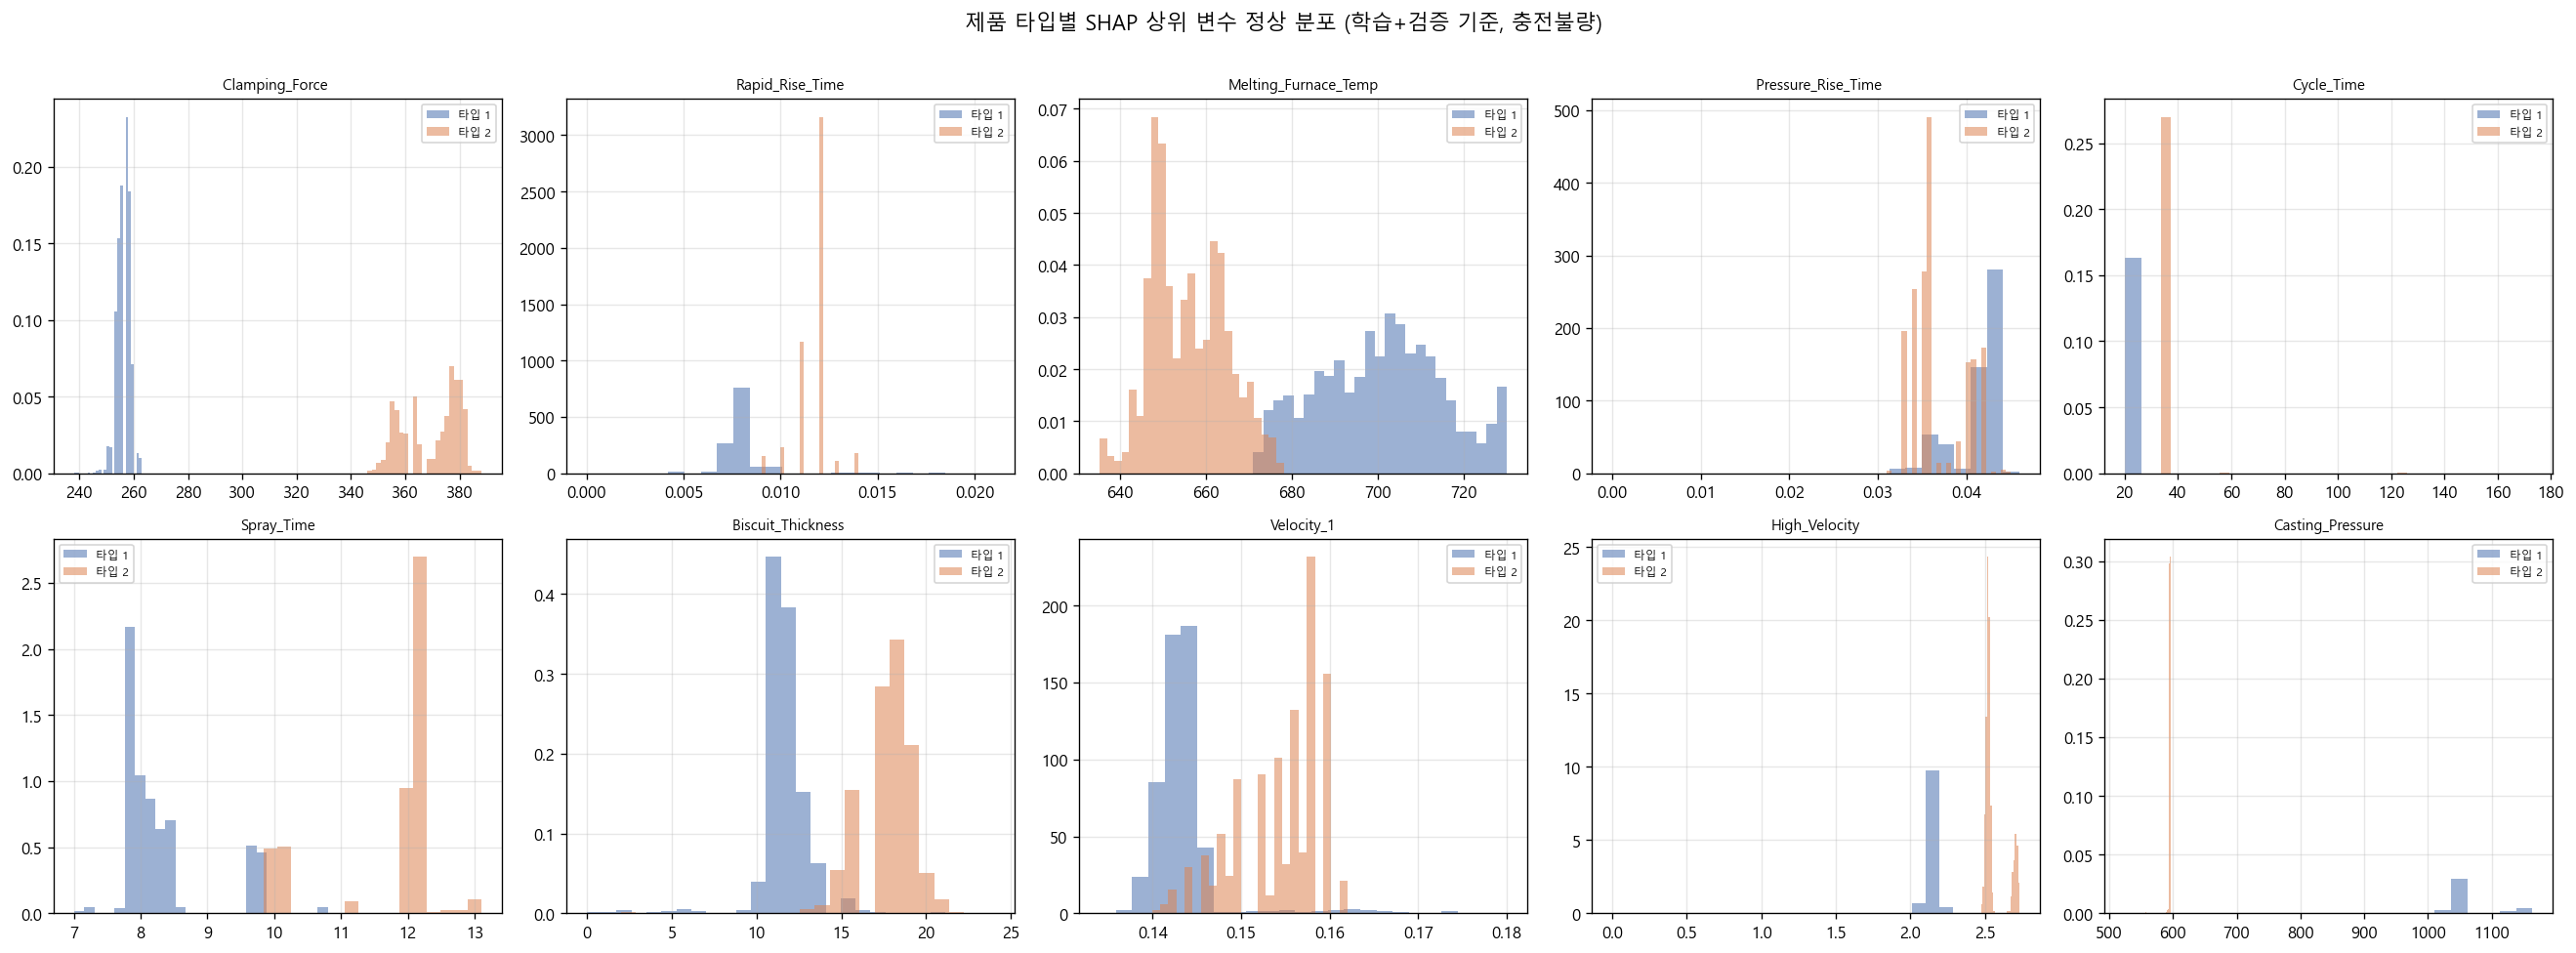

In [31]:
# Product Type 기준 분리
# SHAP Top 변수 선택
# Train+Valid 정상 범위

TOP_N = 10

# SHAP Top 변수 목록
top_features = shap_importance.head(TOP_N)['feature'].tolist()

# Product Type 컬럼
pt_col_raw = ('Process', 'Product_Type')
pt_col_model = None
for col in X_raw.columns:
    if 'Product_Type' in col:
        pt_col_model = col
        break

# 기준 모델 결과
ref_key = ("충전불량", "RandomForest")
X_ref_type = final_results[ref_key]['X_train_ref']
y_ref_type = final_results[ref_key]['y_train_ref']
df_ref_raw = df_raw.loc[X_ref_type.index]

# Type별 정상 범위
results_by_type = {}

for pt in [1, 2]:
    # Type별 정상 샘플
    mask_pt = df_ref_raw[pt_col_raw] == pt
    mask_normal = y_ref_type == 0
    mask = mask_pt & mask_normal

    df_pt = X_ref_type.loc[mask, top_features]

    results_by_type[pt] = {
        'median': df_pt.median(),
        'q1': df_pt.quantile(0.25),
        'q3': df_pt.quantile(0.75),
        'n': int(mask.sum())
    }

# Type 기준 비교표
compare_rows = []
for feat in top_features:
    feat_short = feat.replace('Process|', '').replace('Sensor|', '')
    row = {'변수': feat_short}
    for pt in [1, 2]:
        med = results_by_type[pt]['median'][feat]
        q1 = results_by_type[pt]['q1'][feat]
        q3 = results_by_type[pt]['q3'][feat]
        row[f'타입{pt} 중앙값'] = round(med, 3)
        row[f'타입{pt} 정상 IQR'] = f"[{q1:.3f} ~ {q3:.3f}]"
        row[f'타입{pt} 기준수'] = results_by_type[pt]['n']
    compare_rows.append(row)

compare_df = pd.DataFrame(compare_rows)
display(compare_df)

# 정상 분포 시각화
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
colors = {1: '#4C72B0', 2: '#DD8452'}

for i, feat in enumerate(top_features):
    # 변수별 Type 분포
    ax = axes[i]
    feat_short = feat.replace('Process|', '').replace('Sensor|', '')

    for pt in [1, 2]:
        mask_pt = df_ref_raw[pt_col_raw] == pt
        mask_normal = y_ref_type == 0
        data = X_ref_type.loc[mask_pt & mask_normal, feat].dropna()
        ax.hist(data, bins=25, alpha=0.55, color=colors[pt], label=f'타입 {pt}', density=True)

    ax.set_title(feat_short, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('제품 타입별 SHAP 상위 변수 정상 분포 (학습+검증 기준, 충전불량)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 운영 적용 예시

제품 타입 반영 진단 로직
제품 타입 2 샘플 기준 고속속도 주의 신호 확인


In [33]:
# 제품 타입 반영 진단 함수
def diagnosis_report_v2(
    model,
    shap_vals,
    X_test,
    X_ref,          # Train+Valid 기준
    y_ref,          # 기준 라벨
    df_raw,         # Product Type 조회
    sample_idx=0,
    top_n=5
):

    # 샘플 타입 기준 진단

    # 샘플 Product Type
    pt_col = None
    for col in df_raw.columns:
        if 'Product_Type' in str(col):
            pt_col = col
            break
    sample_raw_idx = X_test.index[sample_idx]
    sample_pt = df_raw.loc[sample_raw_idx, pt_col]

    # 불량 확률
    pred_proba = model.predict_proba(X_test.iloc[[sample_idx]])[0, 1]

    # SHAP Top 변수
    sample_shap = shap_vals[sample_idx]

    shap_df = pd.DataFrame({
        'feature': X_test.columns,
        'shap_value': sample_shap,
        'abs_shap': np.abs(sample_shap)
    }).sort_values('abs_shap', ascending=False)
    top_features = shap_df.head(top_n)

    # Type별 정상 기준
    df_ref_raw = df_raw.loc[X_ref.index]
    mask_pt = df_ref_raw[pt_col] == sample_pt
    mask_normal = y_ref == 0
    mask = mask_pt & mask_normal
    df_ref = X_ref.loc[mask]

    # 정상 IQR 범위
    normal_median = df_ref.median()
    normal_q1 = df_ref.quantile(0.25)
    normal_q3 = df_ref.quantile(0.75)

    print(f"제품 타입 {sample_pt}")
    print(f"기준 정상 수 {int(mask.sum())}")
    print(f"불량확률 {pred_proba:.1%}")

    # 위험 등급
    if pred_proba >= 0.7:
        print("고위험")
    elif pred_proba >= 0.4:
        print("주의")
    else:
        print("정상")
    print()
    print(f"원인 변수 상위 {top_n} / 제품 타입 {sample_pt}")

    for rank, (_, row) in enumerate(top_features.iterrows(), 1):
        # 변수별 편차·SHAP
        feat = row['feature']
        current_val = X_test.iloc[sample_idx][feat]
        med = normal_median[feat]
        q1 = normal_q1[feat]
        q3 = normal_q3[feat]

        # 정상 중앙값 대비 편차
        if med != 0:
            deviation_pct = (current_val - med) / abs(med) * 100
        else:
            deviation_pct = 0.0

        shap_direction = "불량↑" if row['shap_value'] > 0 else "정상↓"

        # IQR 기준 위험 판정
        if row['shap_value'] > 0:
            if current_val < q1 or current_val > q3:
                risk = "위험"
            else:
                risk = "주의"
        else:
            risk = "정상"
        feat_short = feat.replace('Process|','').replace('Sensor|','')

        print(f"  {rank}. {feat_short}")
        print(f"     기준 중앙값: {med:.2f} | 현재: {current_val:.2f}")
        print(f"     정상 범위: [{q1:.2f} ~ {q3:.2f}] | 편차: {deviation_pct:+.1f}%")
        print(f"     SHAP 방향: {shap_direction} | {risk}")


diagnosis_report_v2(
    model=final_results[("충전불량","RandomForest")]['model_obj'],
    shap_vals=shap_vals,
    X_test=final_results[("충전불량","RandomForest")]['X_test'],
    X_ref=final_results[("충전불량","RandomForest")]['X_train_ref'],
    y_ref=final_results[("충전불량","RandomForest")]['y_train_ref'],
    df_raw=df_raw,
    sample_idx=0,
    top_n=5
)


제품 타입 1
기준 정상 수 3197
불량확률 3.4%
정상

원인 변수 상위 5 / 제품 타입 1
  1. Rapid_Rise_Time
     기준 중앙값: 0.01 | 현재: 0.01
     정상 범위: [0.01 ~ 0.01] | 편차: +0.0%
     SHAP 방향: 정상↓ | 정상
  2. Coolant_Pressure
     기준 중앙값: 2.72 | 현재: 2.77
     정상 범위: [2.69 ~ 2.75] | 편차: +1.8%
     SHAP 방향: 정상↓ | 정상
  3. Cycle_Time
     기준 중앙값: 20.90 | 현재: 20.70
     정상 범위: [20.70 ~ 21.20] | 편차: -1.0%
     SHAP 방향: 정상↓ | 정상
  4.  Pressure_Rise_Time
     기준 중앙값: 0.04 | 현재: 0.04
     정상 범위: [0.04 ~ 0.04] | 편차: +0.0%
     SHAP 방향: 정상↓ | 정상
  5. High_Velocity
     기준 중앙값: 2.14 | 현재: 2.13
     정상 범위: [2.12 ~ 2.15] | 편차: -0.4%
     SHAP 방향: 정상↓ | 정상


In [34]:
# Type 2 Test 샘플 탐색
# Train+Valid 기준 진단
# Type 2 인덱스
type2_indices = df_raw[df_raw[('Process', 'Product_Type')] == 2.0].index

# Test 내 Type 2 위치
target_idx_list = [i for i, idx in enumerate(final_results[("충전불량","RandomForest")]['X_test'].index)
                   if idx in type2_indices]

if target_idx_list:
    # Type 2 샘플 진단
    diagnosis_report_v2(
        model=final_results[("충전불량","RandomForest")]['model_obj'],
        shap_vals=shap_vals,
        X_test=final_results[("충전불량","RandomForest")]['X_test'],
        X_ref=final_results[("충전불량","RandomForest")]['X_train_ref'],
        y_ref=final_results[("충전불량","RandomForest")]['y_train_ref'],
        df_raw=df_raw,
        sample_idx=target_idx_list[0],
        top_n=5
    )
else:
    print("테스트 데이터에 제품 타입 2 샘플 없음")


제품 타입 2
기준 정상 수 2295
불량확률 5.0%
정상

원인 변수 상위 5 / 제품 타입 2
  1. Coolant_Pressure
     기준 중앙값: 2.70 | 현재: 2.75
     정상 범위: [2.63 ~ 2.74] | 편차: +1.9%
     SHAP 방향: 정상↓ | 정상
  2. Coolant_Temp
     기준 중앙값: 26.90 | 현재: 26.30
     정상 범위: [26.50 ~ 27.30] | 편차: -2.2%
     SHAP 방향: 정상↓ | 정상
  3.  Pressure_Rise_Time
     기준 중앙값: 0.04 | 현재: 0.04
     정상 범위: [0.03 ~ 0.04] | 편차: +16.7%
     SHAP 방향: 정상↓ | 정상
  4. Cycle_Time
     기준 중앙값: 36.00 | 현재: 36.00
     정상 범위: [35.80 ~ 36.10] | 편차: +0.0%
     SHAP 방향: 정상↓ | 정상
  5. Factory_Humidity
     기준 중앙값: 64.00 | 현재: 64.10
     정상 범위: [61.30 ~ 69.00] | 편차: +0.2%
     SHAP 방향: 정상↓ | 정상
